# RC Charging Circuit

Determine the time constant and steady-state voltage of an RC series circuit driven by a DC source. The analytical solution V(t) = V_s(1 - e^(-t/RC)) provides exact expected values. The SPICE simulation solves the same circuit numerically — agreement between them validates the model and toolchain.

## Assumptions
- Ideal DC voltage source (zero output impedance)
- Ideal resistor (no parasitic inductance or capacitance)
- Ideal capacitor (no ESR, no leakage current)
- Zero initial charge on capacitor (V_C(0) = 0)
- No wire resistance or contact resistance
- Room temperature (no temperature derating)

In [1]:
# Symbolic derivation — RC charging circuit
import sympy as sp

t, R, C, Vs = sp.symbols("t R C V_s", positive=True)
tau = R * C

# Capacitor voltage during charging: V_C(t) = V_s * (1 - exp(-t/tau))
V_C = Vs * (1 - sp.exp(-t / tau))

# At t = tau: V_C = V_s * (1 - 1/e) ≈ 63.2% of V_s
V_at_tau = sp.simplify(V_C.subs(t, tau))

# Steady state: t -> inf
V_steady = sp.limit(V_C, t, sp.oo)

print(f"V_C(t) = {V_C}")
print(f"V_C(tau) = {V_at_tau} = V_s * {float(1 - sp.exp(-1)):.4f}")
print(f"V_C(inf) = {V_steady}")

V_C(t) = V_s*(1 - exp(-t/(C*R)))
V_C(tau) = -V_s*exp(-1) + V_s = V_s * 0.6321
V_C(inf) = V_s


In [2]:
# Plug in actual values with pint + uncertainties
import pint
from uncertainties import ufloat

ureg = pint.UnitRegistry()

V_SOURCE = 5.0 * ureg.V                         # DC supply
RESISTANCE = ufloat(1.0, 0.05) * ureg.kohm      # 1.0 kOhm +/-5%, generic thick film
CAPACITANCE = ufloat(10.0, 1.0) * ureg.uF       # 10 uF +/-10%, generic MLCC

TAU = (RESISTANCE * CAPACITANCE).to(ureg.ms)     # RC time constant

print(f"V_source: {V_SOURCE}")
print(f"R: {RESISTANCE}")
print(f"C: {CAPACITANCE}")
print(f"tau = RC: {TAU}")
print(f"tau nominal: {TAU.magnitude.nominal_value:.2f} ms")
print(f"tau uncertainty: {TAU.magnitude.std_dev:.2f} ms ({TAU.magnitude.std_dev / TAU.magnitude.nominal_value * 100:.1f}%)")

V_source: 5.0 volt
R: 1.00+/-0.05 kiloohm
C: 10.0+/-1.0 microfarad
tau = RC: 10.0+/-1.1 millisecond
tau nominal: 10.00 ms
tau uncertainty: 1.12 ms (11.2%)


## Expected Values
- **Time constant:** tau = 10.00 +/- 1.12 ms (propagated from R and C tolerances)
- **Final voltage:** V_C(inf) = 5.0 V (charges to source voltage)
- **Initial voltage:** V_C(0) = 0.0 V (uncharged capacitor)
- **At t = tau:** V_C(tau) = 3.16 V (63.2% of V_source)

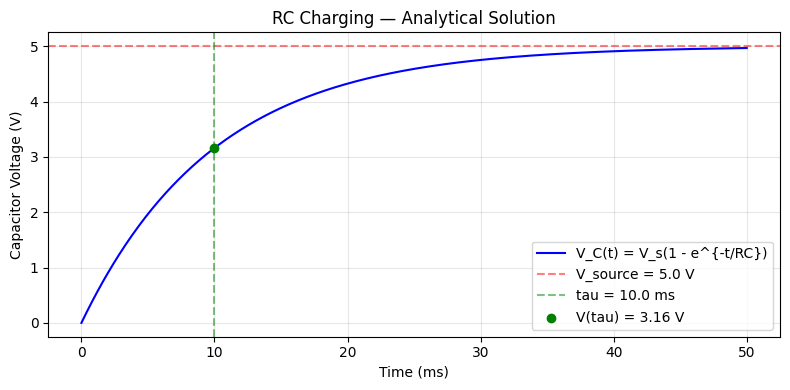

In [3]:
# Verification plot — ideal RC charging curve
import numpy as np
import matplotlib.pyplot as plt

v_s = V_SOURCE.magnitude
tau_nom = TAU.magnitude.nominal_value
t_ms = np.linspace(0, 50, 500)
v_cap = v_s * (1 - np.exp(-t_ms / tau_nom))

plt.figure(figsize=(8, 4))
plt.plot(t_ms, v_cap, "b-", label="V_C(t) = V_s(1 - e^{-t/RC})")
plt.axhline(v_s, color="r", linestyle="--", alpha=0.5, label=f"V_source = {v_s} V")
plt.axvline(tau_nom, color="g", linestyle="--", alpha=0.5, label=f"tau = {tau_nom:.1f} ms")
plt.scatter([tau_nom], [v_s * (1 - np.exp(-1))], color="g", zorder=5, label=f"V(tau) = {v_s * (1 - np.exp(-1)):.2f} V")
plt.xlabel("Time (ms)")
plt.ylabel("Capacitor Voltage (V)")
plt.title("RC Charging — Analytical Solution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sim/results/rc_charging.png", dpi=150)
plt.show()